# Task 3: Customer Churn Prediction
**Objective:** Build and evaluate machine learning models (Logistic Regression, Random Forest, XGBoost/Gradient Boosting) to predict customer churn.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

## Step 1: Load and Inspect Dataset

In [6]:
# Load dataset (Replace filename if your uploaded file has a different name)
df = pd.read_csv('Churn_Modelling.csv')

# View basic information
print("First 5 rows:")
print(df.head())

# Drop identifier columns if present (e.g., customerID)
if 'customerID' in df.columns:
    df.drop('customerID', axis=1, inplace=True)

# Convert TotalCharges to numeric (fix spaces/blank strings if any)
if 'TotalCharges' in df.columns:
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
    df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

print("\nMissing values remaining:", df.isnull().sum().sum())

First 5 rows:
   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  
0        101348.88       1  
1        112542.58       0  
2        113931.57       1  
3         93826.63       0  

## Step 2: Preprocess & Encode Categorical Features
Convert categorical text features into numerical values for machine learning.

In [9]:
# Separate target ('Exited') and features
target_name = 'Exited'

# Clean binary target variable
y = df[target_name]

# Drop identifier columns and the target column from features
drop_cols = ['RowNumber', 'CustomerId', 'Surname', target_name]
X_raw = df.drop(columns=[col for col in drop_cols if col in df.columns])

# One-Hot Encode categorical variables (Geography, Gender)
X = pd.get_dummies(X_raw, drop_first=True)

# Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Target column: '{target_name}'")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

Target column: 'Exited'
X_train shape: (8000, 11)
X_test shape: (2000, 11)


## Step 3: Train & Compare Multiple ML Models
1. Logistic Regression
2. Random Forest
3. Gradient Boosting

In [10]:
# Initialize models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

results = []

for name, model in models.items():
    # Use scaled features for Logistic Regression, raw split for trees
    if name == 'Logistic Regression':
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    # Calculate metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1
    })

# Display comparison summary
results_df = pd.DataFrame(results)
print("=== Churn Model Performance Comparison ===")
print(results_df.to_string(index=False))

=== Churn Model Performance Comparison ===
              Model  Accuracy  Precision   Recall  F1-Score
Logistic Regression    0.8080   0.589147 0.186732  0.283582
      Random Forest    0.8645   0.783333 0.461916  0.581144
  Gradient Boosting    0.8700   0.792829 0.488943  0.604863


## Step 4: Feature Importance (Which factors drive customer churn?)

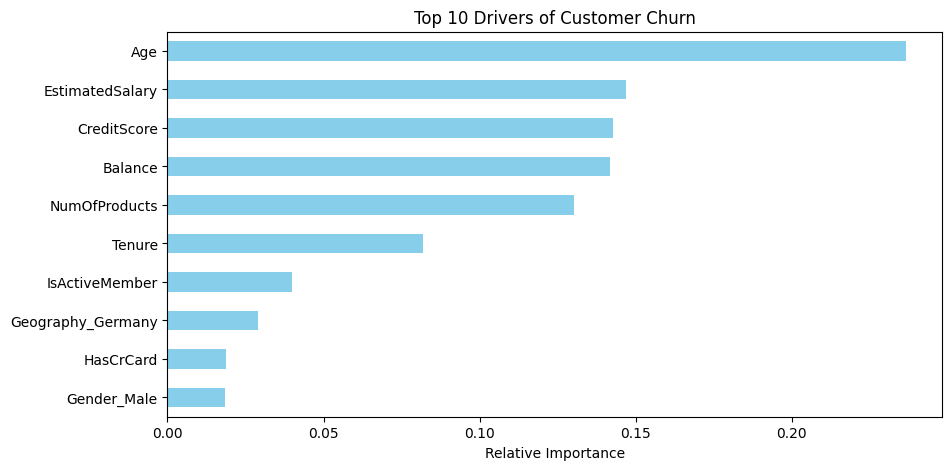

In [11]:
# Analyze feature importance from Random Forest
rf_model = models['Random Forest']
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

# Plot top 10 important features
plt.figure(figsize=(10, 5))
importances.head(10).plot(kind='barh', color='skyblue')
plt.title('Top 10 Drivers of Customer Churn')
plt.gca().invert_yaxis()
plt.xlabel('Relative Importance')
plt.show()